In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.7.12


In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path

from cmdstanpy import CmdStanModel
import culRIBayesian.stan_utils as culRIB
import culRIBayesian.dataviz_utils as dv
import importlib

import bayspline as bsl
import bayspar as bsr



In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(66.6667,-18.6667),
        'schouteN_meso003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(0.015,0.280),
        'schouteN_meso003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [5]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)

In [6]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [7]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/culRIBayesian/stan_models/'

## Ensure a freshly compiled stan files

In [8]:
def refresh_stan_models():
    """
    This function compiles the Stan models in the specified directory.
    It removes any existing binaries and recompiles the models,
    injecting the necessary TBB_CXX_TYPE variable for Stan.
    """
    print("Compiling Stan models...")
    import subprocess
    from pathlib import Path
    import os

    # Define the Stan models directory
    stan_dir = Path(stan_models_path)

    # Prepare environment with TBB_CXX_TYPE
    env = os.environ.copy()
    env["TBB_CXX_TYPE"] = "gcc"

    # Optional: Clean previous builds
    print("Cleaning previous Stan builds...")
    subprocess.run(["make", "clean"], cwd=stan_dir, env=env)

    # Find all .stan files in the directory
    stan_files = list(stan_dir.glob("*.stan"))

    # Recompile each Stan model
    for stan_file in stan_files:
        binary_file = stan_file.with_suffix("")  # e.g., model.stan -> model (executable)

        # Remove the existing binary
        if binary_file.exists():
            print(f"Removing old binary: {binary_file.name}")
            binary_file.unlink()

        # Compile the Stan model with environment
        print(f"Compiling: {stan_file.name}")
        result = subprocess.run(["make", binary_file.name], cwd=stan_dir, env=env)

        if result.returncode != 0:
            print(f"❌ Compilation failed for {stan_file.name}")
        else:
            print(f"✅ Successfully compiled {binary_file.name}")

    print("Stan models compiled successfully.")

refresh_stan_models()

Compiling Stan models...
Cleaning previous Stan builds...
Compiling: jnt_cul_meso_crtp.stan
❌ Compilation failed for jnt_cul_meso_crtp.stan
Compiling: invT_logistic_fixed_multiv_meanprior_bayes.stan
❌ Compilation failed for invT_logistic_fixed_multiv_meanprior_bayes.stan
Compiling: invT_logistic_fixed_univ.stan
❌ Compilation failed for invT_logistic_fixed_univ.stan
Compiling: hier_crtp_univ_priorApprox.stan
❌ Compilation failed for hier_crtp_univ_priorApprox.stan
Compiling: jnt_cul_meso.stan
❌ Compilation failed for jnt_cul_meso.stan
Compiling: jnt_cul_meso_hier_crtp_multiv.stan
❌ Compilation failed for jnt_cul_meso_hier_crtp_multiv.stan
Compiling: jnt_cul_meso_hier_crtp_multiv_archive.stan
❌ Compilation failed for jnt_cul_meso_hier_crtp_multiv_archive.stan
Compiling: invT_logistic_fixed_multiv.stan
❌ Compilation failed for invT_logistic_fixed_multiv.stan
Compiling: invT_logistic_fixed_univ_meanprior_bayes.stan
❌ Compilation failed for invT_logistic_fixed_univ_meanprior_bayes.stan
Comp

make: *** No rule to make target 'clean'.  Stop.
make: *** No rule to make target 'jnt_cul_meso_crtp'.  Stop.
make: *** No rule to make target 'invT_logistic_fixed_multiv_meanprior_bayes'.  Stop.
make: *** No rule to make target 'invT_logistic_fixed_univ'.  Stop.
make: *** No rule to make target 'hier_crtp_univ_priorApprox'.  Stop.
make: *** No rule to make target 'jnt_cul_meso'.  Stop.
make: *** No rule to make target 'jnt_cul_meso_hier_crtp_multiv'.  Stop.
make: *** No rule to make target 'jnt_cul_meso_hier_crtp_multiv_archive'.  Stop.
make: *** No rule to make target 'invT_logistic_fixed_multiv'.  Stop.
make: *** No rule to make target 'invT_logistic_fixed_univ_meanprior_bayes'.  Stop.
make: *** No rule to make target 'jnt_culmeso_hier_crtp_logistic_fixed_multiv'.  Stop.
make: *** No rule to make target 'jnt_cul_meso_hier_crtp'.  Stop.
make: *** No rule to make target 'hier_crtp_univ_priorLogMixture'.  Stop.
make: *** No rule to make target 'jnt_cul_meso_hier_crtp_archive'.  Stop.


In [9]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [10]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
fname = 'woa23_decav91C0_t00_04.nc'

T_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
woas23_sst = T_da.isel(depth=0).t_an
woas23_sst

<xarray.DataArray 't_an' (time: 1, lat: 720, lon: 1440)>
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
    depth    float32 0.0
  * time     (time) float32 1.878e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [11]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds_tmp = xr.open_dataset(os.path.join(fpath, fname))
ocean_properties_ds = xr.merge(
    [ocean_properties_ds_tmp, woas23_sst.rename('sst')],
    compat='override',
    join='override'
)
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
    depth          float32 0.0
  * time           (time) float64 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                (lat: 720, lon: 1440)
Coordinates:
  * lat                    (lat) float32 -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                    (lon) float32 -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables: (12/14)
    region_ID              (lon, lat) float64 ...
    tex_count              (lon, lat) float64 ...
    tex_median             (lon, lat) float64 ...
    tex_mean               (lon, lat) float64 ...
    tex_std                (lon, lat) float64 ...
    scaledRI_count         (lon, lat) float64 ...
    ...                     ...
    scaledRI_std           (lon, lat) float64 ...
    gdgt23ratio_count      (lon, lat) float64 ...
    gdgt23ratio_median     (lon, lat) float64 ...
    gdgt23ratio_mean       (lon, lat) float64 ...
    gdgt23ratio_std        (lon, lat) float64 ...
    modernWaterDepth_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [12]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])



coretop_df = coretop_ds_merged.to_dataframe()
coretop_df = coretop_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median',
                                                             'gdgt23ratio_median',
                                                             't_sf2tc_avg']).reset_index()
coretop_df

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,1.502839,NaN,928.0,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.833333,NaN,1081.0,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,1.824832,NaN,332.0,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.066396,NaN,932.0,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.040640,NaN,839.0,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4.516129,NaN,4018.0,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041
1461,86.625,152.125,1878.0,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,...,21.272727,NaN,1467.0,7.059811,9.083502,-1.156047,175.0,0.24909,0.0,-1.57041
1462,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,9.555556,NaN,3368.0,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180
1463,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,2.870370,NaN,4443.0,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371


In [13]:
# ─── prepare sample points ────────────────────────────────────────────────────
xx = np.linspace(-4, 50, 200)

# ─── filter & group your data ──────────────────────────────────────────────────
plot_data = culture_meso_df[culture_meso_df['Temperature'] < 50]
min_count = 2
groups = [g for g, df in plot_data.groupby('Strains_edited') if len(df) >= min_count]

# ─── build the figure with one trace per strain per model ─────────────────────
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=coretop_df['t_sf2tc_avg'],
    y=coretop_df['scaledRI_median'],
    mode='markers',
    marker=dict(color='rgba(178,178,178,1.000)', size=5),
    name='Core-top data',
    showlegend=True   # you can allow toggling it via legend if you like
))
core_idx = 0  # index of this core-top trace

# ─── add global fits ────────────────────────────────────────────────
X_all = plot_data['Temperature'].values.reshape(-1,1)
y_all = plot_data['scaledRI'].values

# -- Linear fit --
ols_all = LinearRegression().fit(X_all, y_all)
y_lin_all = ols_all.predict(xx.reshape(-1,1))


# -- Logistic fixed upper --
p0f = [25, 0.1, 0.1]
bf = (0, [50,1,1])
popt_f_all, _ = curve_fit(logistic_fixed_upper, plot_data['Temperature'], plot_data['scaledRI'], p0=p0f, bounds=bf)
y_logif_all = logistic_fixed_upper(xx, *popt_f_all)
r2_logif_all = 1 - np.var(plot_data['scaledRI'] - logistic_fixed_upper(plot_data['Temperature'], *popt_f_all)) / np.var(plot_data['scaledRI'])

# -- Full logistic --
p0_all = [25,0.1,0.1,0.1]
bnd_all = (0, [50,1,1,1])
popt_all, _ = curve_fit(logistic, plot_data['Temperature'], plot_data['scaledRI'], p0=p0_all, bounds=bnd_all)
y_logi_all = logistic(xx, *popt_all)
r2_logi_all = 1 - np.var(plot_data['scaledRI'] - logistic(plot_data['Temperature'], *popt_all)) / np.var(plot_data['scaledRI'])

## add global fits to figure
for model, y, r2 in [
    ("Linear", y_lin_all, ols_all.score(X_all, y_all)),
    ("Logistic fixed", y_logif_all, r2_logif_all),
    ("Logistic", y_logi_all, r2_logi_all)
]:
    fig.add_trace(go.Scatter(
        x=xx, y=y,
        mode='lines',
        name=f"glob_cul_meso -- {model} (R²={r2:.2f})",
        visible=True
    ))

### add X_all and y_all with coretop data and fit the glob_cul_meso_crtp
X_all_full = np.concatenate((coretop_df['t_sf2tc_avg'].values.reshape(-1,1), plot_data['Temperature'].values.reshape(-1,1)))
y_all_full = np.concatenate((coretop_df['scaledRI_median'].values, plot_data['scaledRI'].values))

# -- Linear fit --
ols_all_full = LinearRegression().fit(X_all_full, y_all_full)
y_lin_all_full = ols_all_full.predict(xx.reshape(-1,1))
# -- Logistic fixed upper --
p0f_full = [25, 0.1, 0.1]
bf_full = (0, [50,1,1])
popt_f_all_full, _ = curve_fit(logistic_fixed_upper, np.squeeze(X_all_full), y_all_full, p0=p0f_full, bounds=bf_full)
y_logif_all_full = logistic_fixed_upper(xx, *popt_f_all_full)
r2_logif_all_full = 1 - np.var(y_all_full - logistic_fixed_upper(X_all_full, *popt_f_all_full)) / np.var(y_all_full)
# -- Full logistic --
p0_all_full = [25,0.1,0.1,0.1]
bnd_all_full = (0, [50,1,1,1])
popt_all_full, _ = curve_fit(logistic, np.squeeze(X_all_full), y_all_full, p0=p0_all_full, bounds=bnd_all_full)
y_logi_all_full = logistic(xx, *popt_all_full)
r2_logi_all_full = 1 - np.var(y_all_full - logistic(X_all_full, *popt_all_full)) / np.var(y_all_full)
## add global fits to figure
for model, y, r2 in [
    ("Linear", y_lin_all_full, ols_all_full.score(X_all_full, y_all_full)),
    ("Logistic fixed", y_logif_all_full, r2_logif_all_full),
    ("Logistic", y_logi_all_full, r2_logi_all_full)
]:
    fig.add_trace(go.Scatter(
        x=xx, y=y,
        mode='lines',
        name=f"glob_cul_meso_crtp -- {model} (R²={r2:.2f})",
        visible=True
    ))
    
# ─── add all your strain traces ───────────────────────────
for strain in groups:
    df = plot_data[plot_data['Strains_edited'] == strain]
    X = df['Temperature'].values.reshape(-1,1)
    y = df['scaledRI'].values
    
    # -- Linear fit --
    ols = LinearRegression().fit(X, y)
    y_lin = ols.predict(xx.reshape(-1,1))
    fig.add_trace(go.Scatter(
        x=xx, y=y_lin, 
        mode='lines',
        name=f"{strain} -- Linear (R²={ols.score(X,y):.2f})",
        visible=(strain == groups[0])  # only first strain visible initially
    ))
    
    # -- Logistic fixed upper --
    p0f = [25, 0.1, 0.1]
    bf = (0, [50,1,1])
    popt_f, _ = curve_fit(logistic_fixed_upper, df['Temperature'], df['scaledRI'], p0=p0f, bounds=bf)
    y_logf = logistic_fixed_upper(xx, *popt_f)
    r2_f = 1 - np.var(df['scaledRI'] - logistic_fixed_upper(df['Temperature'], *popt_f)) / np.var(df['scaledRI'])
    fig.add_trace(go.Scatter(
        x=xx, y=y_logf,
        mode='lines',
        name=f"{strain} -- Logistic fixed (R²={r2_f:.2f})",
        visible=False
    ))
    
    # -- Full logistic --
    p0 = [25,0.1,0.1,0.1]
    bnd = (0, [50,1,1,1])
    popt, _ = curve_fit(logistic, df['Temperature'], df['scaledRI'], p0=p0, bounds=bnd)
    y_log = logistic(xx, *popt)
    r2 = 1 - np.var(df['scaledRI'] - logistic(df['Temperature'], *popt)) / np.var(df['scaledRI'])
    fig.add_trace(go.Scatter(
        x=xx, y=y_log,
        mode='lines',
        name=f"{strain} -- Logistic (R²={r2:.2f})",
        visible=False
    ))
    
    # -- Always-on scatter of raw data --
    fig.add_trace(go.Scatter(
        x=df['Temperature'], y=df['scaledRI'],
        mode='markers',
        marker=dict(size=6, line=dict(width=1, color='black')),
        name=f"{strain} -- data",
        visible=True
    ))
# build a mapping strain → color
palette1 = px.colors.qualitative.Set1
palette2 = px.colors.qualitative.Set2

# make one long list
all_colors = palette1 + palette2

# then map strains in order
strain_colors = {
    strain: all_colors[i % len(all_colors)]
    for i, strain in enumerate(groups)
}

# now loop through all traces
for trace in fig.data:
    # The “cultures + mesocosm only” global fit
    if trace.name.startswith("glob_cul_meso --"):
        trace.update(line=dict(
            color="black",   # pick any CSS name or hex code
            dash="solid",        # “solid”, “dash”, “dot”, “dashdot”, etc
            width=4              # thicker line
        ))

    # The “cultures + mesocosm + coretop” global fit
    elif trace.name.startswith("glob_cul_meso_crtp --"):
        trace.update(line=dict(
            color="black",
            dash="dashdot",
            width=3
        ))
        
    # skip the core-top (and any other truly global or background traces)
    elif trace.name == "Core-top data":
        continue

    # split off the strain name (everything before the “ – ”)
    strain = trace.name.split(" -- ")[0]

    # pick a color: if it’s one of our strains, use its palette color;
    # otherwise (e.g. “Global”) fall back to black or whatever you like
    col = strain_colors.get(strain, "black")

    # apply to both marker & line
    trace.update(
        marker=dict(color=col),
        line=dict(color=col)
    )



# Hide all line traces (fits) by default, leave markers visible
for trace in fig.data:
    if "lines" in trace.mode:
        trace.visible = "legendonly"
    else:
        trace.visible = True

# # Make “raw data” the initial visibility state:
# for tr in fig.data:
#     if tr.name == "Core-top data" or tr.name.endswith("-- data"):
#         tr.visible = True
#     else:
#         tr.visible = False
        


# reposition the model‐dropdown as a vertical nav bar on the left
fig.update_layout(

    autosize=False,     # turn off responsive “fill the container”
    width=900,          # fixed pixel width
    height=500,         # fixed pixel height
    margin=dict(l=40, r=40, t=50, b=40),

    title="Scaled RI vs Temperature",
    xaxis_title="Temperature (°C)",
    yaxis_title="Scaled RI",
    
    yaxis=dict(
        range=[0.1, 1.1],
        autorange=False    # turn off auto‐scaling
    ),

    # put the legend also on the left, so users can click each strain on/off
    legend=dict(
        traceorder="normal",
        orientation="v",
        x=1.13,      # just inside the left margin
        y=0.5,
        xanchor="left",
        yanchor="middle",
        itemsizing="constant"
    ),
    template='seaborn',
    font=dict(
        family="TeX Gyre Heros",
        size=14,
        color="black"
    ),
    
)

# lock X/Y so the units match (remove if you don’t want a 1:1 scale)
fig.update_xaxes(constrain='domain')            # keep the X‐axis from expanding

# set a default
# fig.update_layout(template="plotly_white")

fig.show()

# in your Python script / notebook:
fig.write_html(
  os.path.join(local_github_path, 'html_figures', 'scaledRI_vs_Temperature.html'),
  include_plotlyjs="cdn",   # pull Plotly.js from the CDN
  full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)


In [14]:
culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture']
culture_data_full = culture_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                        'scaledRI',
                                                                                        'gdgt23ratio']).reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm']
meso_data_full = meso_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                'scaledRI',
                                                                                'gdgt23ratio']).reset_index(drop=True)

coretop_df = coretop_df.replace([np.inf, -np.inf],np.nan).dropna(subset=['scaledRI_median',
                                                                         't_sf2tc_avg',
                                                                         'no3_sf2tc_avg',
                                                                         'gdgt23ratio_median']).reset_index(drop=True)
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)
coretop_df['gdgt23ratio_median'].max()


35.072441830778935

# Input Data for stan models

In [15]:
t_cul = culture_data_full['Temperature'].astype(float).tolist() 
scaledRI_cul = culture_data_full['scaledRI'].astype(float).tolist() 
gdgt23ratio_cul = culture_data_full['gdgt23ratio'].astype(float).tolist()

t_meso = meso_data_full['Temperature'].astype(float).tolist()
scaledRI_meso = meso_data_full['scaledRI'].astype(float).tolist()
gdgt23ratio_meso = meso_data_full['gdgt23ratio'].astype(float).tolist()

t_crtp = coretop_df['t_sf2tc_avg'].astype(float).tolist()
sst_crtp = coretop_df['sst'].astype(float).tolist()
scaledRI_crtp = coretop_df['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = coretop_df['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = coretop_df['no3_sf2tc_avg'].astype(float).tolist()


# Calibration posteriors

## jnt_cul_meso

In [16]:
# Save data for Stan
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
}

stan_file_name = 'jnt_cul_meso'
jnt_cul_meso_post_ds, diag = culRIB.get_posterior(data, 
                                                  stan_file_name,
                                                  temptype='cultureT')


# Save posteriors
culRIB.save_posterior(jnt_cul_meso_post_ds)


14:53:56 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso


ValueError: Failed to compile Stan model '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso.stan'. Console:
stan/lib/stan_math/make/libraries:114: *** "Need to set TBB_CXX_TYPE for non-standard compiler other than gcc or clang.".  Stop.

Command ['make', '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso']
	error during processing No such file or directory


## hier-crtp | log-mixture

In [ ]:
n_draws = 1000
sel = np.random.choice(jnt_cul_meso_post_ds.dims["draw"], size=n_draws, replace=True)

data = {
    "N_crtp": len(coretop_df),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    
    "M": n_draws,
    "t0": jnt_cul_meso_post_ds['t0_culmeso'].isel(draw=sel).values.tolist(),
    "k": jnt_cul_meso_post_ds['k_culmeso'].isel(draw=sel).values.tolist(),
    "b": jnt_cul_meso_post_ds['b_culmeso'].isel(draw=sel).values.tolist(),
    "sigma_scaledRI": jnt_cul_meso_post_ds['sigma_scaledRI_culmeso'].isel(draw=sel).values.tolist(),
    
    "mixture_sigma": 0.2,  # Set a small value for the mixture sigma
    
}

stan_file_name = 'hier_crtp_univ_priorLogMixture'
hier_crtp_univ_prior_logmixture_post_ds, diag = culRIB.get_posterior(data, 
                                                                     stan_file_name,
                                                                     temptype='thermoT',)
# Save posteriors
culRIB.save_posterior(hier_crtp_univ_prior_logmixture_post_ds)


data = {
    "N_crtp": len(coretop_df),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    
    "M": n_draws,
    "t0": jnt_cul_meso_post_ds['t0_culmeso'].isel(draw=sel).values.tolist(),
    "k": jnt_cul_meso_post_ds['k_culmeso'].isel(draw=sel).values.tolist(),
    "b": jnt_cul_meso_post_ds['b_culmeso'].isel(draw=sel).values.tolist(),
    "sigma_scaledRI": jnt_cul_meso_post_ds['sigma_scaledRI_culmeso'].isel(draw=sel).values.tolist(),
    
    "mixture_sigma": 0.2,  # Set a small value for the mixture sigma
    
}

stan_file_name = 'hier_crtp_univ_priorLogMixture'
hier_crtp_sst_univ_prior_logmixture_post_ds, diag = culRIB.get_posterior(data, 
                                                                     stan_file_name,
                                                                     temptype='sst',)
# Save posteriors
culRIB.save_posterior(hier_crtp_sst_univ_prior_logmixture_post_ds)

16:08:02 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorLogMixture.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorLogMixture
16:08:09 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorLogMixture
16:08:09 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

16:08:26 - cmdstanpy - INFO - CmdStan done processing.
16:08:26 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorLogMixture.stan', line 50, column 4 to column 52)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorLogMixture.stan', line 50, column 4 to column 52)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorLogMixture.stan', line 50, column 4 to column 52)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorLogMixture.stan', line 50, column 4 to column 52)


Sampling completed in 9.7 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_priorLogMixture_sst.nc


PosixPath('/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_priorLogMixture_sst.nc')

## hier_crtp | prior approximation

In [ ]:
prior_mean_t0 = jnt_cul_meso_post_ds["t0_culmeso"].mean(dim="draw").item()
prior_sd_t0 = jnt_cul_meso_post_ds["t0_culmeso"].std(dim="draw").item()

prior_mean_k = jnt_cul_meso_post_ds["k_culmeso"].mean(dim="draw").item()
prior_sd_k = jnt_cul_meso_post_ds["k_culmeso"].std(dim="draw").item()

prior_mean_b = jnt_cul_meso_post_ds["b_culmeso"].mean(dim="draw").item()
prior_sd_b = jnt_cul_meso_post_ds["b_culmeso"].std(dim="draw").item()


In [ ]:
data_normal_prior = {
    "N_crtp": len(coretop_df),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_univ_priorApprox'
hier_crtp_univ_prior_approx_post_ds, diag = culRIB.get_posterior(data_normal_prior, 
                                                                 stan_file_name,
                                                                 temptype='thermoT',)
# Save posteriors
culRIB.save_posterior(hier_crtp_univ_prior_approx_post_ds)

data_normal_prior = {
    "N_crtp": len(coretop_df),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_univ_priorApprox'
hier_crtp_sst_univ_prior_approx_post_ds, diag = culRIB.get_posterior(data_normal_prior, 
                                                                 stan_file_name,
                                                                 temptype='sst',)
# Save posteriors
culRIB.save_posterior(hier_crtp_sst_univ_prior_approx_post_ds)

16:08:27 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox
16:08:34 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox
16:08:34 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

16:08:40 - cmdstanpy - INFO - CmdStan done processing.
16:08:40 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 50)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 50)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 50)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 50)
	Exception: no


Sampling completed in 3.1 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_priorApprox_sst.nc


PosixPath('/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/hier_crtp_univ_priorApprox_sst.nc')

## jnt_cul_meso_crtp

In [ ]:
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_post_ds, diag = culRIB.get_posterior(data, 
                                                       stan_file_name,
                                                       temptype='thermoT')
display(jnt_cul_meso_crtp_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_crtp_post_ds)

##########################################################
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_sst_post_ds, diag = culRIB.get_posterior(data, 
                                                           stan_file_name,
                                                           temptype='sst')
display(jnt_cul_meso_crtp_sst_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_crtp_sst_post_ds)


16:08:40 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp
16:08:47 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp
16:08:47 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

16:08:54 - cmdstanpy - INFO - CmdStan done processing.
16:08:54 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.99313, but must be in the interval [0, 1] (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 42, column 2 to column 65)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 40, column 2 to column 66)
Exception: normal_lpdf: Location parameter[1] is nan, but must be finite! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan', line 40, column 2 to column 66)
Exception: beta_lpdf: Rando


Sampling completed in 3.9 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



<xarray.Dataset>
Dimensions:              (draw: 4000)
Coordinates:
  * draw                 (draw) int64 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
Data variables:
    t0_culmesocore       (draw) float64 29.54 29.63 30.05 ... 30.06 29.26 30.0
    k_culmesocore        (draw) float64 0.111 0.1084 0.1139 ... 0.1094 0.1062
    b_culmesocore        (draw) float64 0.4212 0.4199 0.4312 ... 0.4191 0.423
    sigma_scaledRI_cul   (draw) float64 0.07494 0.08733 ... 0.08453 0.08883
    sigma_scaledRI_meso  (draw) float64 0.07297 0.0677 0.0901 ... 0.06754 0.1007
    sigma_scaledRI_crtp  (draw) float64 0.06418 0.06162 ... 0.06131 0.06123
Attributes: (12/25)
    stan_model_name:     jnt_cul_meso_crtp
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-02T16:08:54.884298
    run_duration (sec):  3.87
    temptype:            sst
    ...                  ...
    scaledRI_crtp_mean:  0.5557237381745532
    scaledRI_crtp_std:   0.11105198051279462
    scaledRI_crtp_min:   0.26446293775
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   1402
    priors:              ['t0_culmesocore: normal(20, 20) T[-4, ]', 'k_culmes...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_crtp_sst.nc


PosixPath('/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_crtp_sst.nc')

## jnt_cul_meso_hier_crtp

In [ ]:
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

}
stan_file_name = 'jnt_cul_meso_hier_crtp'
jnt_cul_meso_hier_crtp_post_ds, diag = culRIB.get_posterior(data, 
                                                            stan_file_name,
                                                            temptype='thermoT',)
display(jnt_cul_meso_hier_crtp_post_ds)
# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_post_ds)

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,

}
stan_file_name = 'jnt_cul_meso_hier_crtp'
jnt_cul_meso_hier_crtp_sst_post_ds, diag = culRIB.get_posterior(data, 
                                                            stan_file_name,
                                                            temptype='sst',)
display(jnt_cul_meso_hier_crtp_sst_post_ds)
# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_post_ds)

16:08:54 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
16:09:02 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
16:09:02 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

16:09:20 - cmdstanpy - INFO - CmdStan done processing.
16:09:20 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 68, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 68, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 68, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan', line 56, column 2 to column 61)
	Exception: normal_lpdf: Scal


Sampling completed in 9.2 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
98 of 1000 (9.80%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:              (draw: 4000)
Coordinates:
  * draw                 (draw) int64 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
Data variables:
    t0_culmeso           (draw) float64 29.79 29.51 30.84 ... 29.44 29.46 29.63
    k_culmeso            (draw) float64 0.1583 0.1548 0.1443 ... 0.1432 0.1414
    b_culmeso            (draw) float64 0.4077 0.4284 0.4505 ... 0.4051 0.4097
    t0_crtp              (draw) float64 29.81 29.58 29.57 ... 29.46 29.4 29.63
    k_crtp               (draw) float64 0.1004 0.109 0.1 ... 0.1058 0.1073
    b_crtp               (draw) float64 0.415 0.419 0.4123 ... 0.412 0.423
    sigma_t0_culmeso     (draw) float64 0.7536 1.117 1.433 ... 0.2633 0.1512
    sigma_k_culmeso      (draw) float64 0.413 0.06995 0.8519 ... 0.8291 1.933
    sigma_b_culmeso      (draw) float64 0.1904 0.06177 ... 0.07547 0.06268
    sigma_scaledRI_cul   (draw) float64 0.0681 0.09026 0.074 ... 0.06987 0.0755
    sigma_scaledRI_meso  (draw) float64 0.1118 0.08507 ... 0.08354 0.09603
    sigma_scaledRI_crtp  (draw) float64 0.0604 0.06118 ... 0.06205 0.06198
Attributes: (12/25)
    stan_model_name:     jnt_cul_meso_hier_crtp
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-02T16:09:20.685692
    run_duration (sec):  9.26
    temptype:            sst
    ...                  ...
    scaledRI_crtp_mean:  0.5557237381745532
    scaledRI_crtp_std:   0.11105198051279462
    scaledRI_crtp_min:   0.26446293775
    scaledRI_crtp_max:   0.8442500000000001
    scaledRI_crtp_len:   1402
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_sst.nc


PosixPath('/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_sst.nc')

['t0', 'k', 'b']


(<Figure size 900x400 with 3 Axes>,
 array([[<AxesSubplot:xlabel='t0'>, <AxesSubplot:xlabel='k'>,
         <AxesSubplot:xlabel='b'>]], dtype=object))

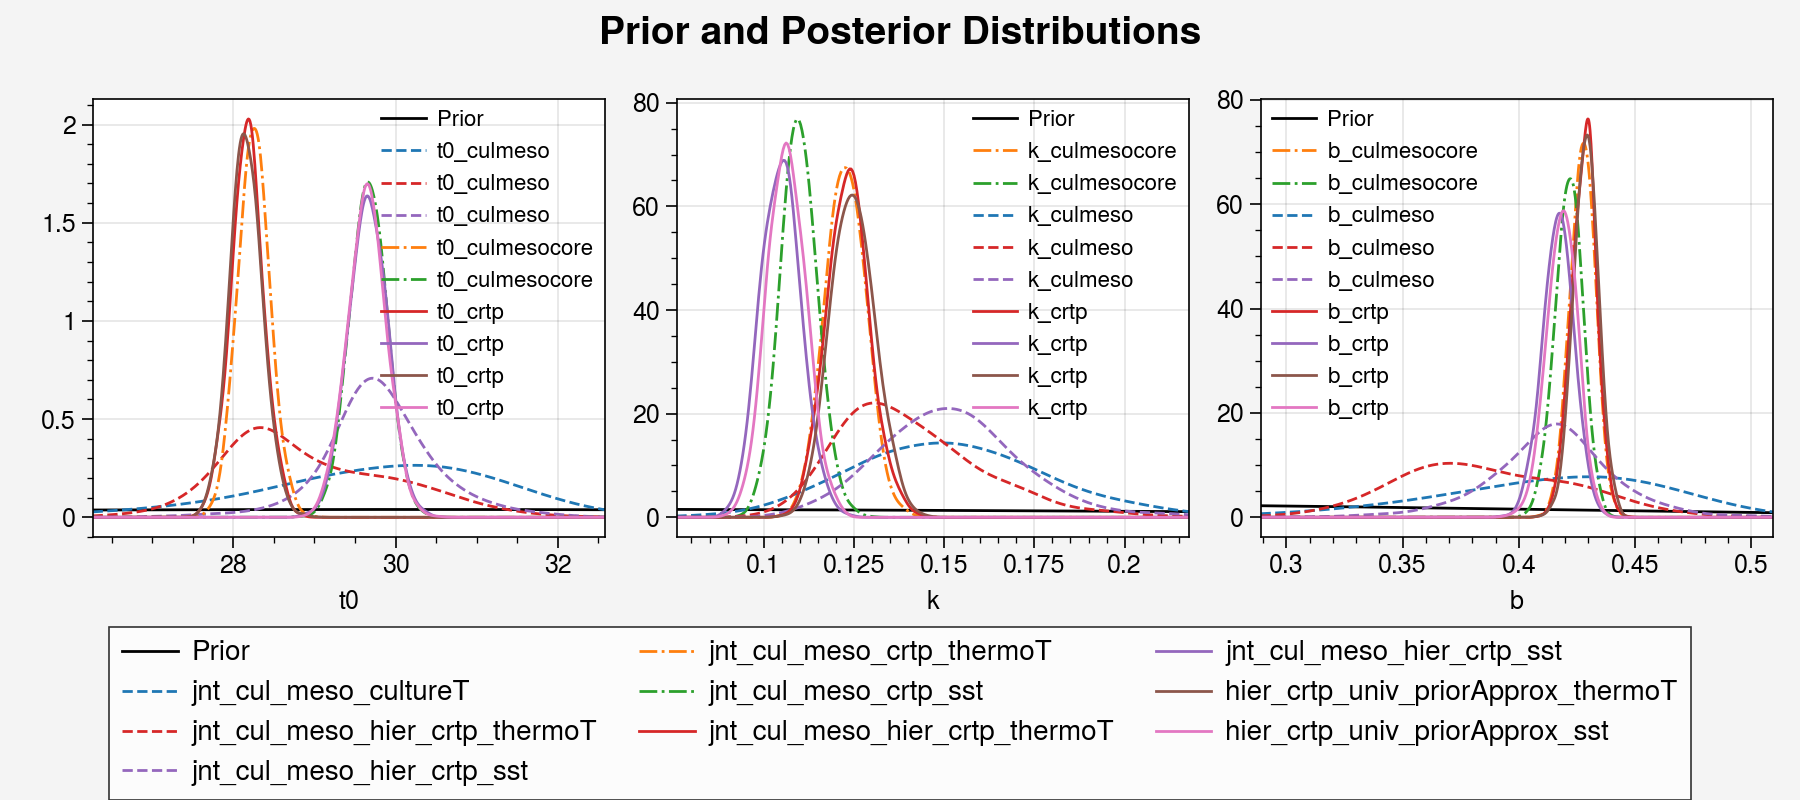

In [ ]:
priors = jnt_cul_meso_post_ds.attrs['priors']
dv.plot_prior_distributions(priors,
                            posterior_datasets=[
                                jnt_cul_meso_post_ds,
                                jnt_cul_meso_crtp_post_ds,
                                jnt_cul_meso_crtp_sst_post_ds,
                                jnt_cul_meso_hier_crtp_post_ds,
                                jnt_cul_meso_hier_crtp_sst_post_ds,
                                # hier_crtp_univ_prior_logmixture_post_ds,
                                hier_crtp_univ_prior_approx_post_ds,
                                # hier_crtp_sst_univ_prior_logmixture_post_ds,
                                hier_crtp_sst_univ_prior_approx_post_ds
                                ],
                            use_linestyle_by_param=True,
                            show_histogram=False,
                            set_linewidth=1,
                            set_bottom_space=0.2,
                            set_fig_height_factor=4
                            )

In [ ]:
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
jnt_cul_meso_hier_crtp_multiv_g23r_post_ds, diag = culRIB.get_posterior(data, 
                                                                        stan_file_name,
                                                                        temptype='thermoT')
display(jnt_cul_meso_hier_crtp_multiv_g23r_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_g23r_post_ds)

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(coretop_df),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    # "no3_crtp": no3_crtp,
    "no3_cutoff": -1 ## set to -1 to not use no3

}
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds, diag = culRIB.get_posterior(data, 
                                                                            stan_file_name,
                                                                            temptype='sst',)
display(jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds)

# Save posteriors
culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_g23r_post_ds)

16:09:26 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
16:09:34 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
16:09:34 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

16:10:12 - cmdstanpy - INFO - CmdStan done processing.
16:10:12 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 71, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 71, column 4 to column 66)
	E


Sampling completed in 16.9 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
89 of 1000 (8.90%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 27.48 30.17 27.8 ... 28.24 27.85
    k_culmeso               (draw) float64 0.1165 0.1351 ... 0.1424 0.1163
    b_culmeso               (draw) float64 0.3494 0.3993 ... 0.3629 0.3239
    t0_crtp                 (draw) float64 27.77 27.66 27.39 ... 27.48 27.82
    k_crtp                  (draw) float64 0.1076 0.09476 ... 0.1081 0.0985
    b_crtp                  (draw) float64 0.4496 0.4267 0.438 ... 0.4479 0.4327
    ...                      ...
    sigma_t0_culmeso        (draw) float64 0.3854 1.558 0.4109 ... 2.528 0.1496
    sigma_k_culmeso         (draw) float64 0.5724 0.2155 ... 0.03926 3.899
    sigma_b_culmeso         (draw) float64 0.07006 3.044 ... 4.993 0.04877
    sigma_scaledRI_cul      (draw) float64 0.07535 0.07983 ... 0.08673 0.06181
    sigma_scaledRI_meso     (draw) float64 0.08248 0.1196 ... 0.1007 0.09949
    sigma_scaledRI_crtp     (draw) float64 0.05636 0.05627 ... 0.05778 0.05613
Attributes: (12/31)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-02T16:10:12.182679
    run_duration (sec):     16.97
    temptype:               sst
    ...                     ...
    gdgt23ratio_crtp_std:   3.4678668194270457
    gdgt23ratio_crtp_min:   0.7564253358305837
    gdgt23ratio_crtp_max:   35.072441830778935
    gdgt23ratio_crtp_len:   1402
    use_gdgt23ratio:        1
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio.nc


PosixPath('/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio.nc')

In [ ]:
no3_cutoff_values = [
    # 0.1, 0.5, 1, 1.5, 2, 2.5, 5, 10, 
    100
    ]
for no3_cutoff in no3_cutoff_values:
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(coretop_df),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds, diag = culRIB.get_posterior(data, 
                                                                                stan_file_name,
                                                                                temptype='thermoT',
                                                                                )
    display(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds)

    # Save posteriors
    culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds)

    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(coretop_df),
        "t_crtp": sst_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds, diag = culRIB.get_posterior(data, 
                                                                                    stan_file_name,
                                                                                    temptype='sst',
                                                                                    )
    display(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds)

    # Save posteriors
    culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_g23r_no3_post_ds)

16:10:12 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

16:11:11 - cmdstanpy - INFO - CmdStan done processing.
16:11:11 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 71, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 71, column 4 to column 66)
	E


Sampling completed in 22.7 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
228 of 1000 (22.80%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  beta0_gdgt23ratio_crtp, sigma_t0_culmeso
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizating your model with additional prior information or a more effective parameterization.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 29.68 29.42 29.49 ... 30.26 30.52
    k_culmeso               (draw) float64 0.1492 0.1554 ... 0.1685 0.1804
    b_culmeso               (draw) float64 0.4162 0.4055 ... 0.4419 0.4292
    t0_crtp                 (draw) float64 29.52 29.56 29.42 ... 29.41 29.42
    k_crtp                  (draw) float64 0.1065 0.1118 ... 0.09755 0.1038
    b_crtp                  (draw) float64 0.4674 0.4743 ... 0.4624 0.4631
    ...                      ...
    sigma_t0_culmeso        (draw) float64 0.5461 0.2157 0.1464 ... 0.8226 1.04
    sigma_k_culmeso         (draw) float64 0.29 1.366 0.5492 ... 0.05808 0.4644
    sigma_b_culmeso         (draw) float64 0.1526 0.1019 ... 0.02559 0.1233
    sigma_scaledRI_cul      (draw) float64 0.0741 0.07239 ... 0.08043 0.06937
    sigma_scaledRI_meso     (draw) float64 0.0909 0.09597 0.1039 ... 0.13 0.121
    sigma_scaledRI_crtp     (draw) float64 0.05496 0.05423 ... 0.05551 0.05547
Attributes: (12/38)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-02T16:11:11.572144
    run_duration (sec):     22.71
    temptype:               sst
    ...                     ...
    no3_crtp_min:           0.0002862779365386814
    no3_crtp_max:           33.803863525390625
    no3_crtp_len:           1402
    use_no3:                1
    no3_cutoff:             100.0
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio_no3_100.0.nc


In [ ]:
no3_cutoff_values = [
    # 0.1, 0.5, 1, 1.5, 2, 2.5, 5, 10, 
    100]
for no3_cutoff in no3_cutoff_values:
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(coretop_df),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        # "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_multiv_no3_post_ds, diag = culRIB.get_posterior(data,
                                                                           stan_file_name,
                                                                           temptype='thermoT',)
    display(jnt_cul_meso_hier_crtp_multiv_no3_post_ds)

    # Save posteriors
    culRIB.save_posterior(jnt_cul_meso_hier_crtp_multiv_no3_post_ds)

    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(coretop_df),
        "t_crtp": sst_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        # "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3
    }
    stan_file_name = 'jnt_cul_meso_hier_crtp_multiv'
    jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds, diag = culRIB.get_posterior(data, 
                                                                               stan_file_name,
                                                                               temptype='sst',)
    display(jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds)

    # Save posteriors
    culRIB.save_posterior(jnt_cul_meso_hier_crtp_sst_multiv_no3_post_ds)

16:11:11 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

16:11:53 - cmdstanpy - INFO - CmdStan done processing.
16:11:53 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 71, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 71, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan', line 70, column 4 to column 63)
	


Sampling completed in 23.1 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
63 of 1000 (6.30%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 28.57 29.12 28.17 ... 31.65 31.08
    k_culmeso               (draw) float64 0.1365 0.1248 0.1368 ... 0.151 0.169
    b_culmeso               (draw) float64 0.3691 0.3563 0.3722 ... 0.4617 0.451
    t0_crtp                 (draw) float64 31.03 31.15 31.32 ... 31.84 31.49
    k_crtp                  (draw) float64 0.1262 0.1253 ... 0.1181 0.1208
    b_crtp                  (draw) float64 0.4596 0.46 0.4466 ... 0.4622 0.4597
    ...                      ...
    sigma_t0_culmeso        (draw) float64 1.486 2.276 3.759 ... 1.251 0.3391
    sigma_k_culmeso         (draw) float64 2.215 1.366 ... 0.09808 0.02489
    sigma_b_culmeso         (draw) float64 0.6631 0.1735 ... 0.06965 0.04297
    sigma_scaledRI_cul      (draw) float64 0.0675 0.06242 ... 0.07069 0.08827
    sigma_scaledRI_meso     (draw) float64 0.1127 0.12 ... 0.09827 0.0796
    sigma_scaledRI_crtp     (draw) float64 0.05819 0.05788 ... 0.05911 0.05882
Attributes: (12/32)
    stan_model_name:     jnt_cul_meso_hier_crtp_multiv
    generated_by:        culRI-Bayesian
    version:             1.0.0
    run_time:            2025-06-02T16:11:53.211434
    run_duration (sec):  23.11
    temptype:            sst
    ...                  ...
    no3_crtp_min:        0.0002862779365386814
    no3_crtp_max:        33.803863525390625
    no3_crtp_len:        1402
    use_no3:             1
    no3_cutoff:          100.0
    priors:              ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culmeso:...

Posterior saved to /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/posterior_cache/jnt_cul_meso_hier_crtp_multiv_sst_no3_100.0.nc


# Posterior plots --- QC

### 1. Joint culture-mesocosm

['t0', 'k', 'b']


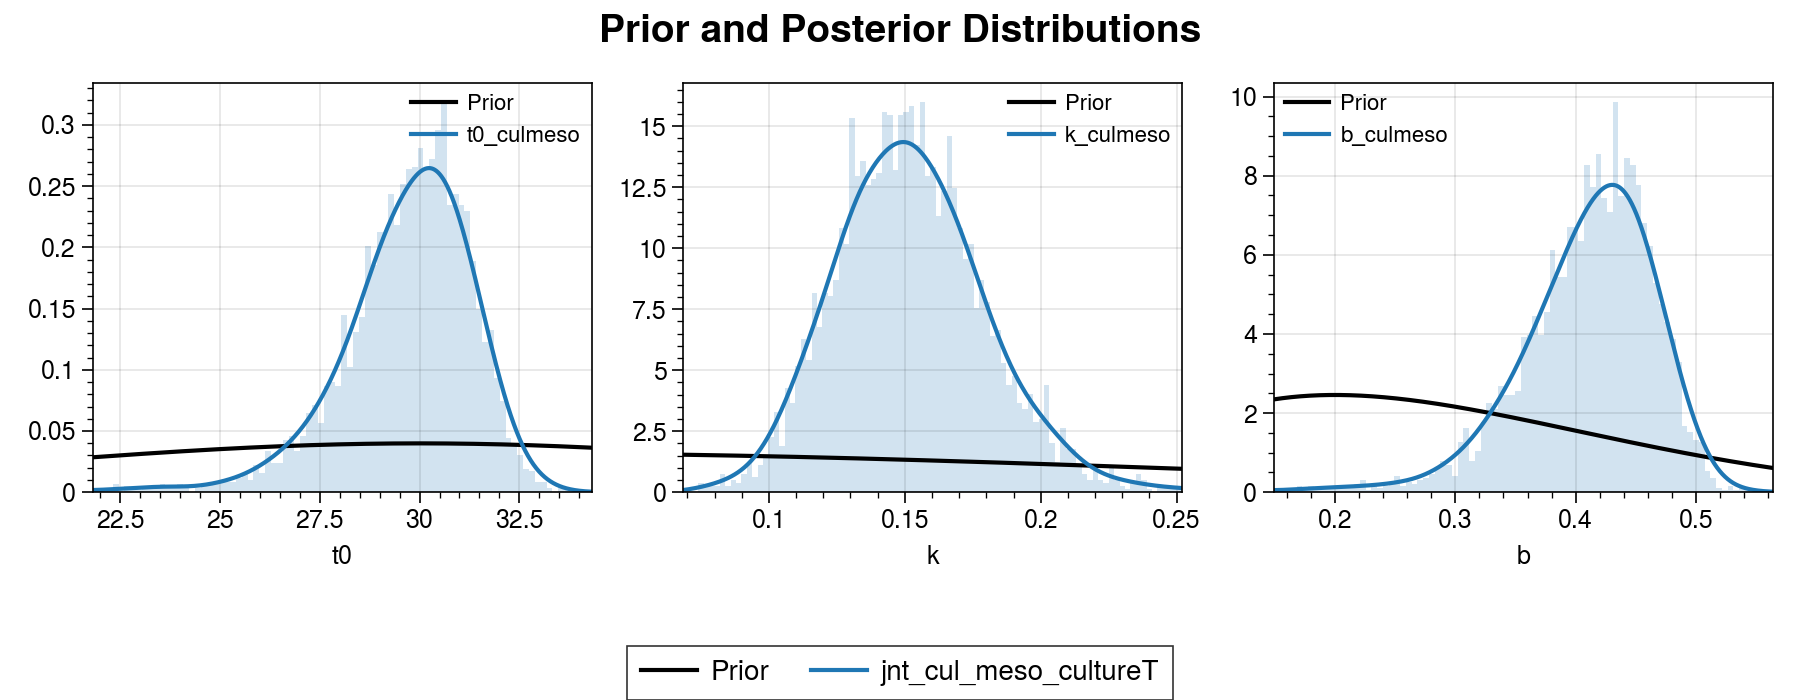

In [ ]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[jnt_cul_meso_post_ds]
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 2. Joint  culture-mesocosm vs culture-mesocosm-coretop

['t0', 'k', 'b']


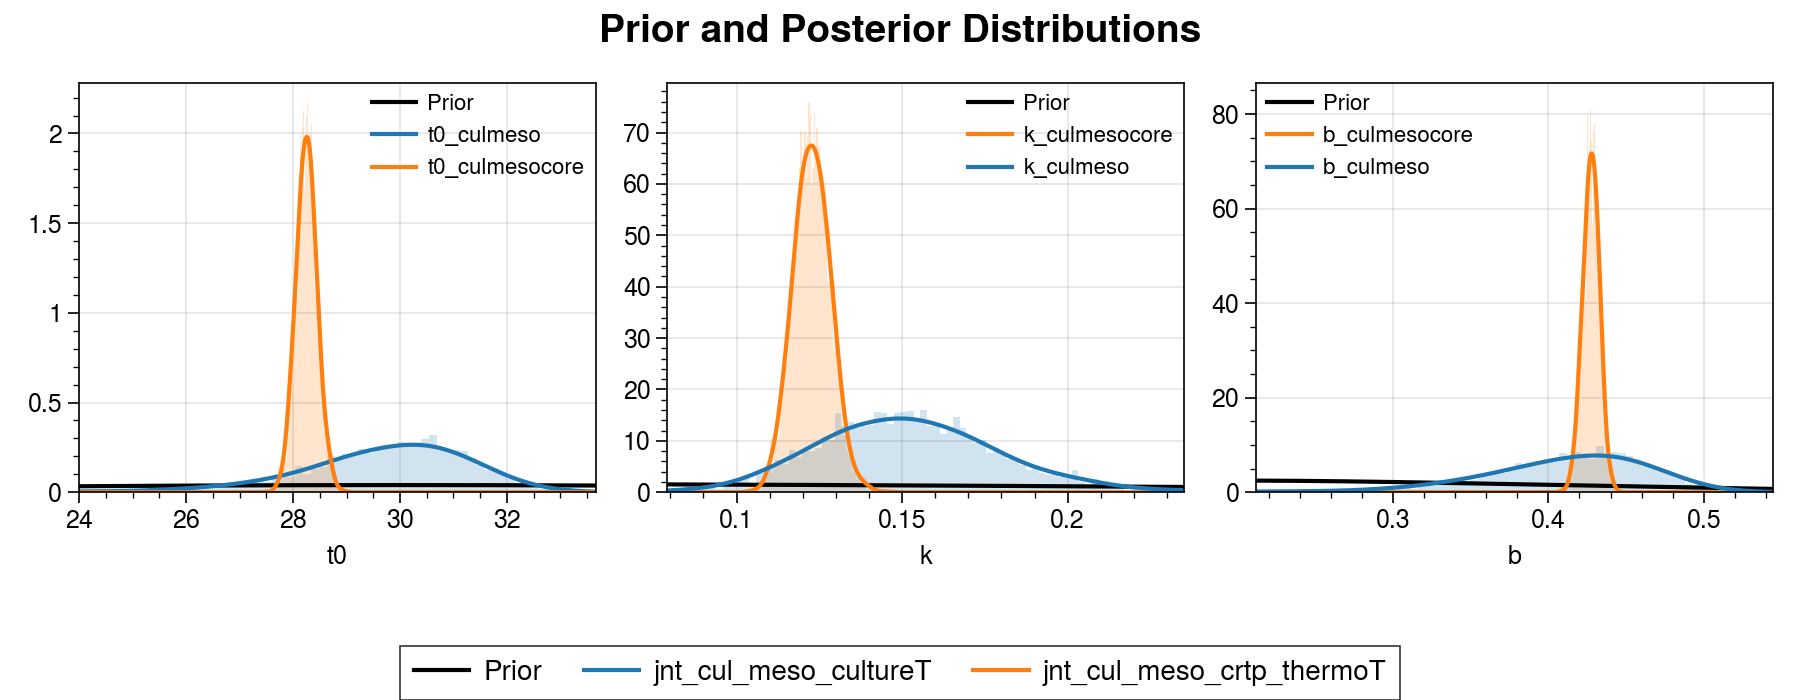

In [ ]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        jnt_cul_meso_crtp_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 3. jnt-culture-mesocosm vs jnt-culture-mesocosm-coretop vs jnt-culmeso-hier-crtp

['t0', 'k', 'b']


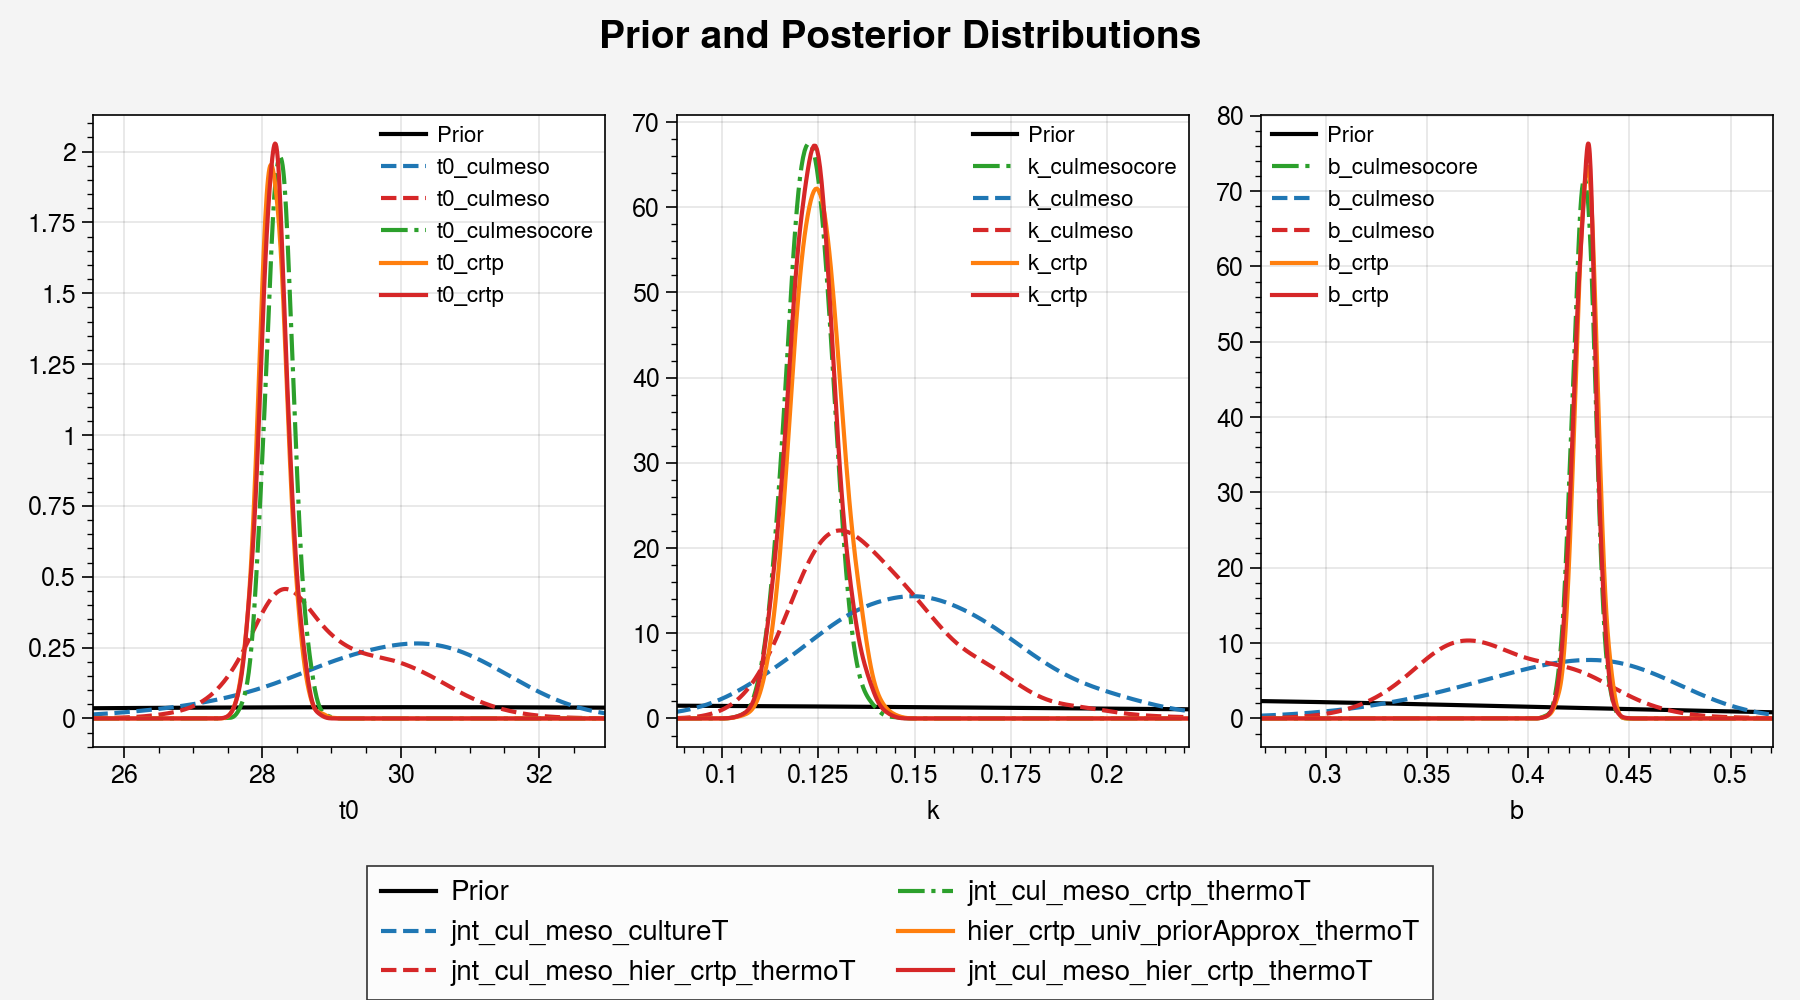

In [ ]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_hier_crtp_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


['t0', 'k', 'b']


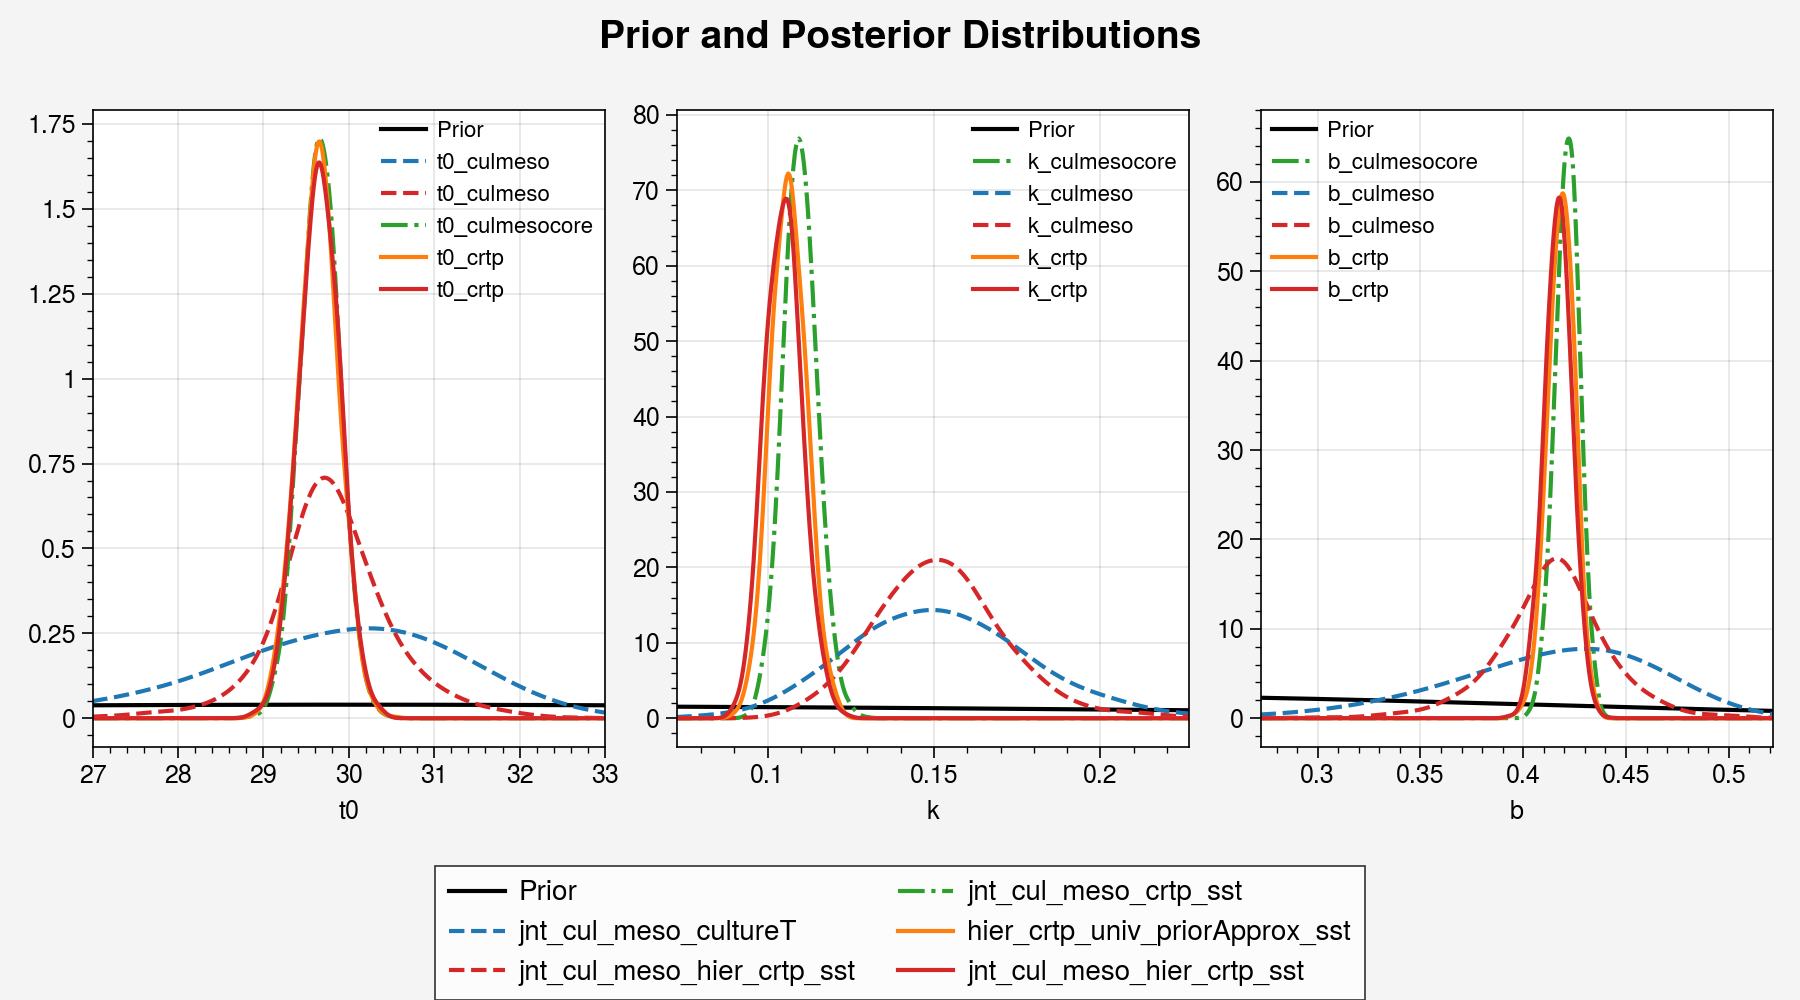

In [ ]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_sst_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_sst_post_ds,
        jnt_cul_meso_hier_crtp_sst_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)
axes[0][0].set_xlim(27,33)
# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


['t0', 'k', 'b']


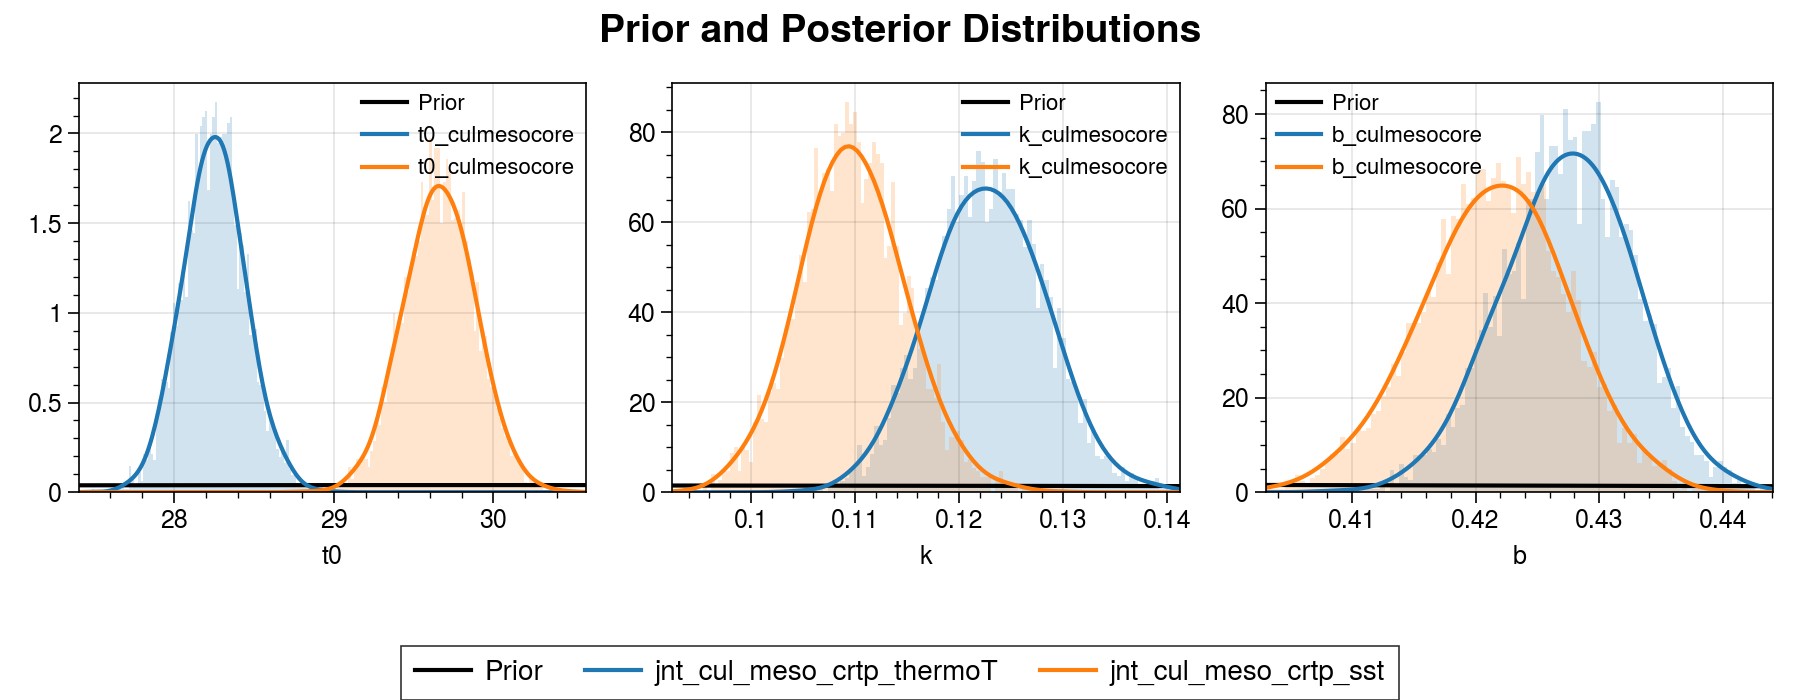

In [ ]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = dv.plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_crtp_sst_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


In [ ]:
jnt_cul_meso_post_ds.attrs.get('use_gdgt23ratio',0)

0

In [ ]:
stan_file_name = 'jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio_no3_100.0'
culRIB.load_posterior(stan_file_name)

<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso              (draw) float64 28.38 28.29 27.77 ... 28.79 29.32
    k_culmeso               (draw) float64 0.1453 0.1261 ... 0.1755 0.1286
    b_culmeso               (draw) float64 0.3789 0.3639 0.358 ... 0.3999 0.3782
    t0_crtp                 (draw) float64 28.21 28.28 28.04 ... 28.15 27.85
    k_crtp                  (draw) float64 0.1176 0.1288 0.135 ... 0.1345 0.1273
    b_crtp                  (draw) float64 0.4629 0.4833 0.4794 ... 0.479 0.4735
    ...                      ...
    sigma_t0_culmeso        (draw) float64 0.3091 0.262 0.3623 ... 0.3576 1.645
    sigma_k_culmeso         (draw) float64 0.05041 0.02285 ... 0.09089 0.02063
    sigma_b_culmeso         (draw) float64 0.1645 0.3695 ... 0.07376 0.1897
    sigma_scaledRI_cul      (draw) float64 0.07507 0.07905 ... 0.07894 0.0749
    sigma_scaledRI_meso     (draw) float64 0.09896 0.09337 ... 0.1088 0.09392
    sigma_scaledRI_crtp     (draw) float64 0.05551 0.05331 ... 0.05304 0.05403
Attributes: (12/39)
    stan_model_name:        jnt_cul_meso_hier_crtp_multiv
    generated_by:           culRI-Bayesian
    version:                1.0.0
    run_time:               2025-06-02T16:10:48.827655
    run_duration (sec):     36.58
    temptype:               thermoT
    ...                     ...
    no3_crtp_max:           33.803863525390625
    no3_crtp_len:           1402
    use_no3:                1
    no3_cutoff:             100.0
    priors:                 ['t0_culmeso: normal(30, 10) T[-1.8, ]', 'k_culme...
    filename:               jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio...

['t0', 'k', 'b', 'beta0_gdgt23ratio', 'beta0_no3']


(25.0, 35.0)

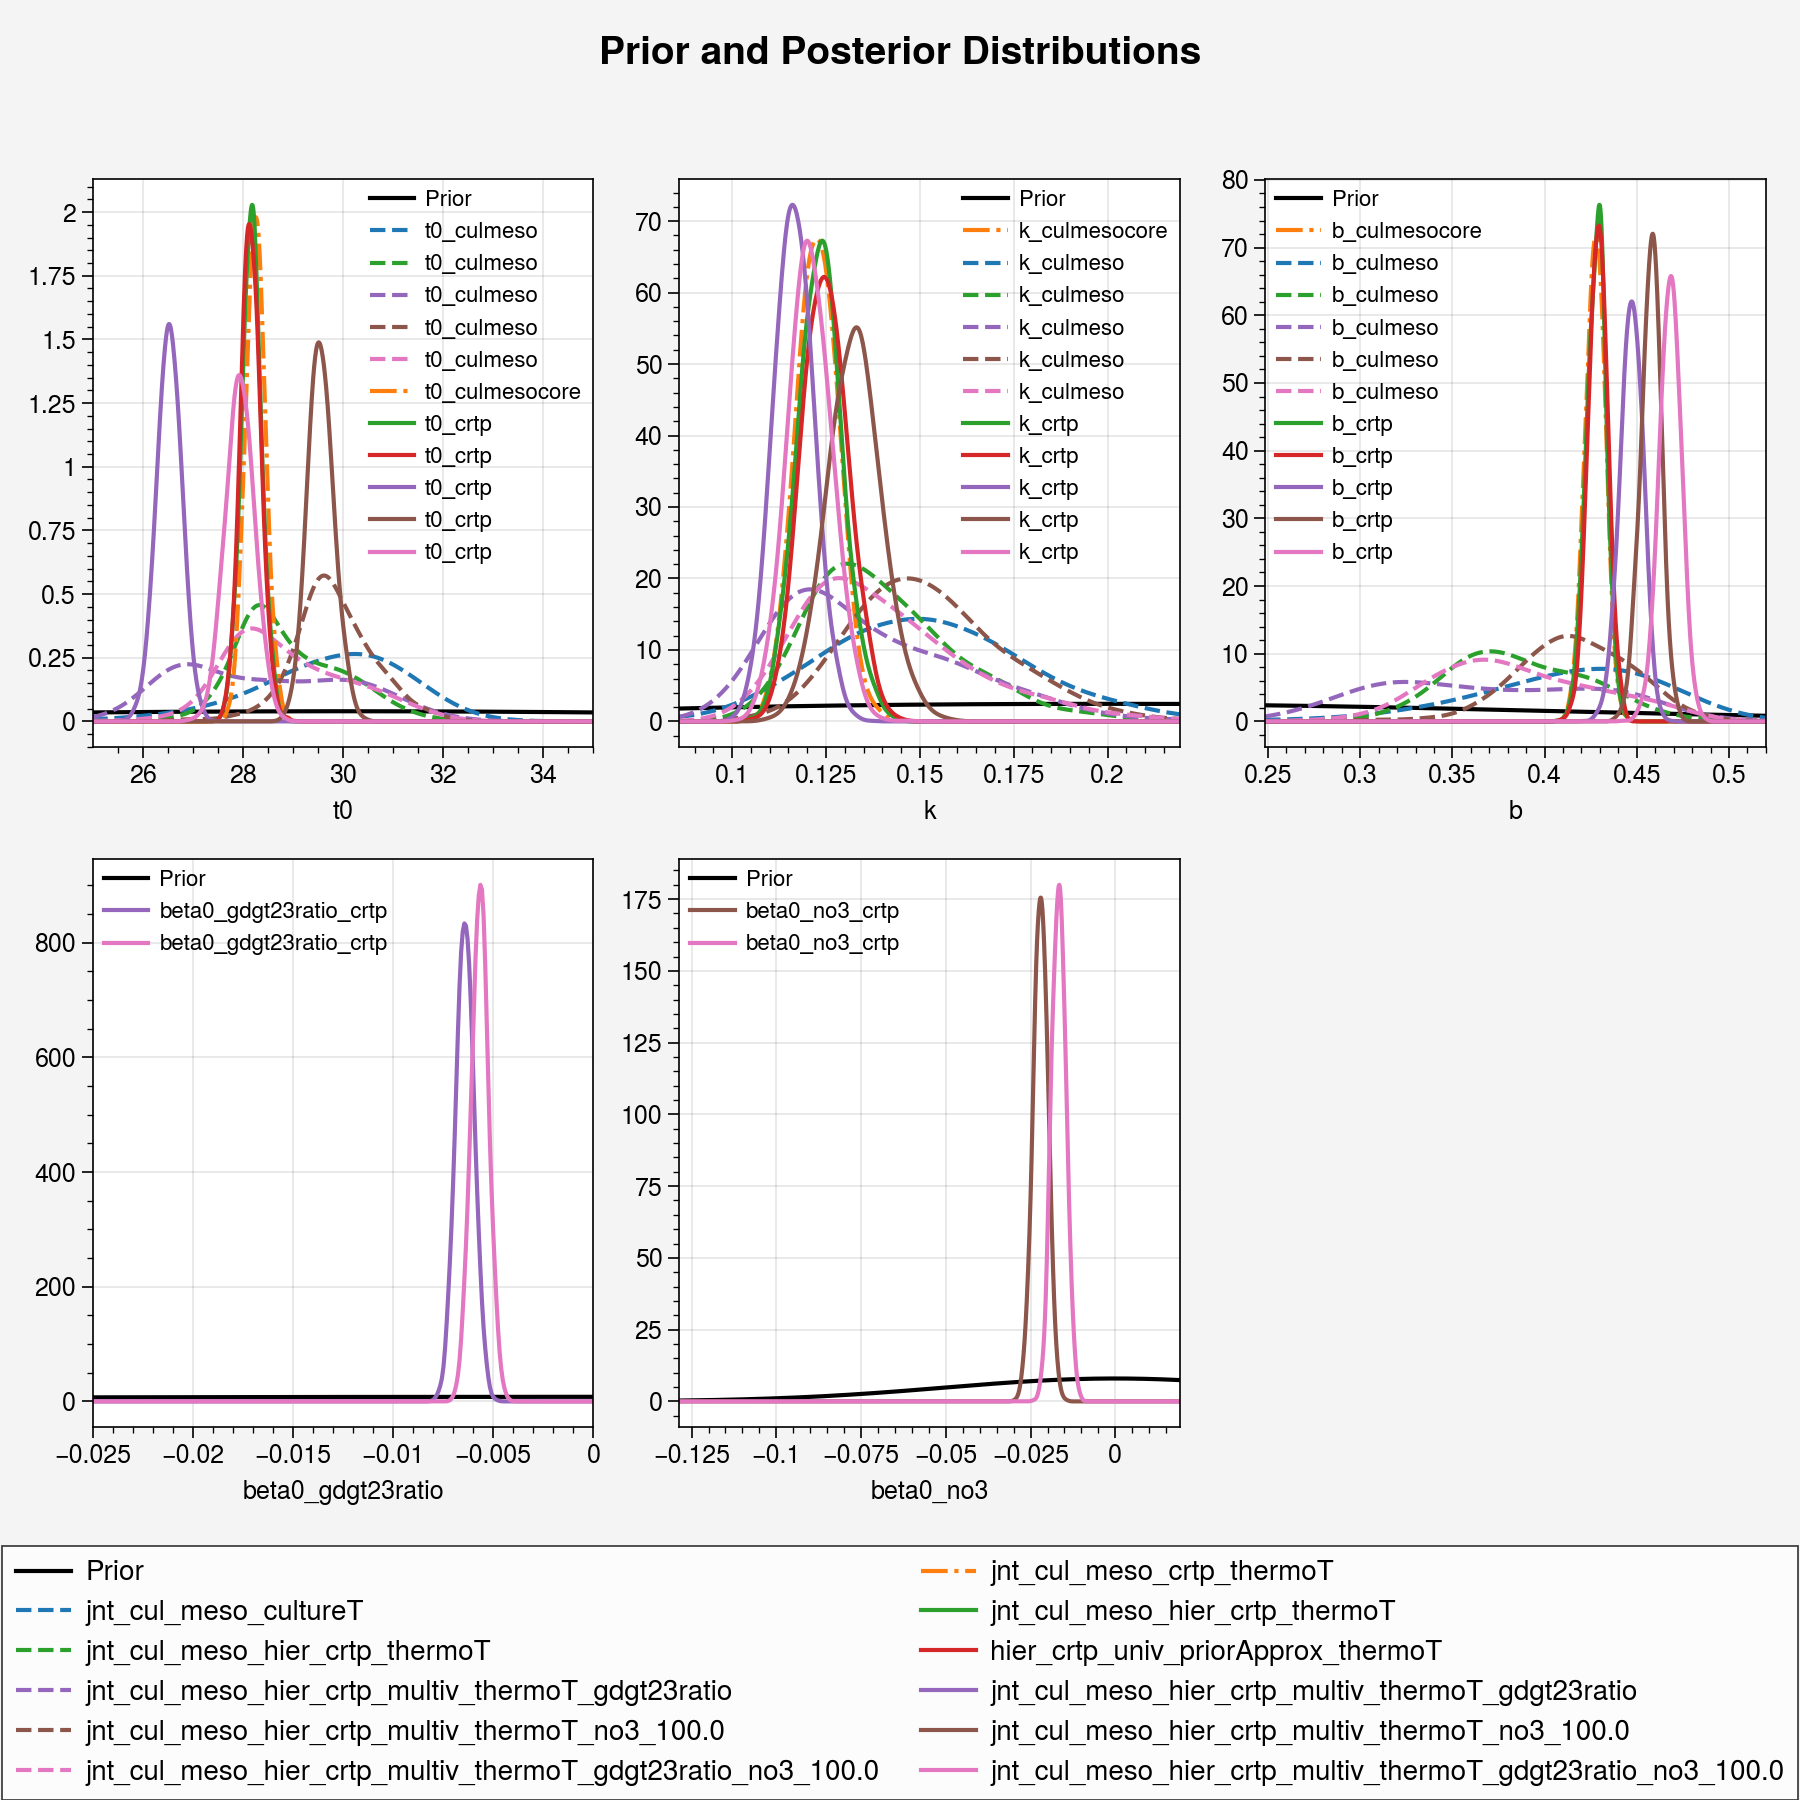

In [ ]:
priors = jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds.attrs['priors']

fig, axes = dv.plot_prior_distributions(
                priors,
                posterior_datasets=[
                    jnt_cul_meso_post_ds,
                    jnt_cul_meso_crtp_post_ds,
                    jnt_cul_meso_hier_crtp_post_ds,
                    hier_crtp_univ_prior_approx_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_g23r_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_no3_post_ds,
                    jnt_cul_meso_hier_crtp_multiv_g23r_no3_post_ds,
                    ],

                # focus_on_posterior=False,
                use_linestyle_by_param=True,
                show_histogram=False,
                set_leg_max_ncol=2,
                set_fig_height_factor=4.5,
                # suffix_include=["crtp","culmesocore"]
                )

axes[1][0].set_xlim(-0.025,0)
axes[0][0].set_xlim(25,35)

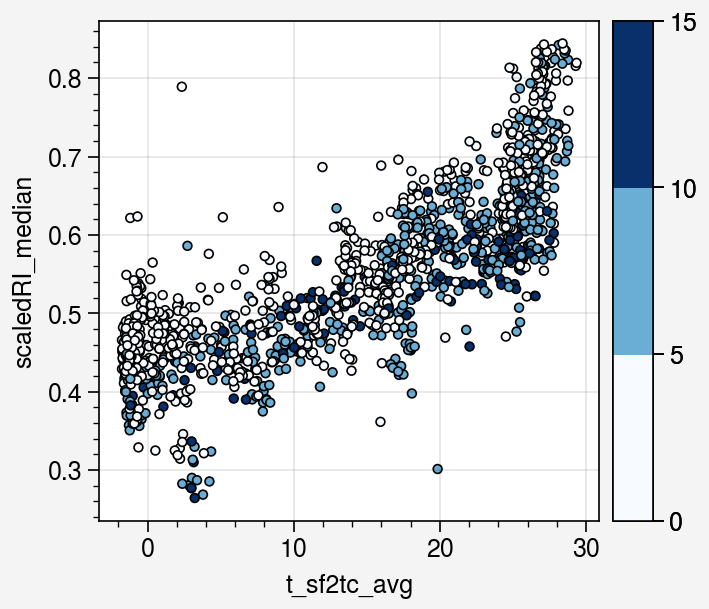

In [ ]:
fig,  axs = plot.subplots()

ax = axs[0]
plot_x = coretop_df['t_sf2tc_avg']
plot_y = coretop_df['scaledRI_median']
plot_c = coretop_df['gdgt23ratio_median']
m = ax.scatter(plot_x, plot_y, s=10, c=plot_c, mec='k', cmap='blues', levels=[0,5,10,15], label='Core-top data')
ax.colorbar(m, loc='r')